In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

In [3]:
vendor = pd.read_csv("Inventory/vendor_invoice.csv")

print("Vendor Invoice:")
print(vendor.head())
print(vendor.columns)

Vendor Invoice:
   VendorNumber                   VendorName InvoiceDate  PONumber  \
0           105  ALTAMAR BRANDS LLC           2024-01-04      8124   
1          4466  AMERICAN VINTAGE BEVERAGE    2024-01-07      8137   
2           388  ATLANTIC IMPORTING COMPANY   2024-01-09      8169   
3           480  BACARDI USA INC              2024-01-12      8106   
4           516  BANFI PRODUCTS CORP          2024-01-07      8170   

       PODate     PayDate  Quantity    Dollars  Freight Approval  
0  2023-12-21  2024-02-16         6     214.26     3.47      NaN  
1  2023-12-22  2024-02-21        15     140.55     8.57      NaN  
2  2023-12-24  2024-02-16         5     106.60     4.61      NaN  
3  2023-12-20  2024-02-05     10100  137483.78  2935.20      NaN  
4  2023-12-24  2024-02-12      1935   15527.25   429.20      NaN  
Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='str')


In [4]:
purchases = pd.read_csv("Inventory/purchases.csv")

print("\nPurchases:")
print(purchases.head())
print(purchases.columns)


Purchases:
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  2024-01-04

In [5]:
prices = pd.read_csv("Inventory/purchase_prices.csv")


print("\nPurchase Prices:")
print(prices.head())
print(prices.columns)


Purchase Prices:
   Brand                  Description  Price   Size Volume  Classification  \
0     58  Gekkeikan Black & Gold Sake  12.99  750mL    750               1   
1     62     Herradura Silver Tequila  36.99  750mL    750               1   
2     63   Herradura Reposado Tequila  38.99  750mL    750               1   
3     72         No. 3 London Dry Gin  34.99  750mL    750               1   
4     75    Three Olives Tomato Vodka  14.99  750mL    750               1   

   PurchasePrice  VendorNumber                   VendorName  
0           9.28          8320  SHAW ROSS INT L IMP LTD      
1          28.67          1128  BROWN-FORMAN CORP            
2          30.46          1128  BROWN-FORMAN CORP            
3          26.11          9165  ULTRA BEVERAGE COMPANY LLP   
4          10.94          7245  PROXIMO SPIRITS INC.         
Index(['Brand', 'Description', 'Price', 'Size', 'Volume', 'Classification',
       'PurchasePrice', 'VendorNumber', 'VendorName'],
      dtyp

In [14]:
vendor.info()

<class 'pandas.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VendorNumber  5543 non-null   int64  
 1   VendorName    5543 non-null   str    
 2   InvoiceDate   5543 non-null   str    
 3   PONumber      5543 non-null   int64  
 4   PODate        5543 non-null   str    
 5   PayDate       5543 non-null   str    
 6   Quantity      5543 non-null   int64  
 7   Dollars       5543 non-null   float64
 8   Freight       5543 non-null   float64
 9   Approval      374 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 433.2 KB


In [16]:
vendor.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0
std,34582.0,1601.0,14453.0,140234.0,714.0
min,2.0,8106.0,1.0,4.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0
50%,7240.0,10890.0,423.0,4765.0,25.0
75%,10754.0,12276.0,5100.0,44587.0,230.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0


In [17]:
vendor[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


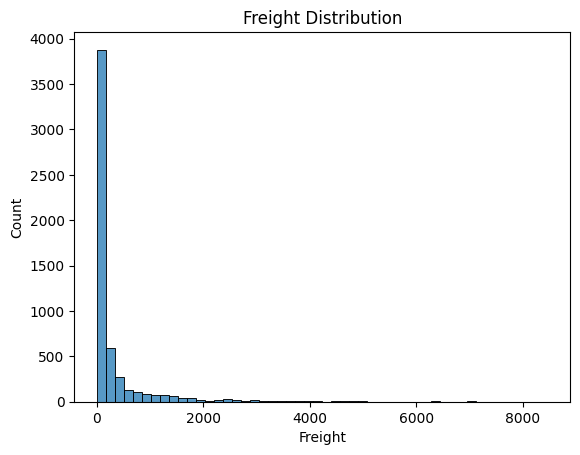

In [19]:
plt.figure()
sns.histplot(vendor['Freight'], bins=50)
plt.title("Freight Distribution")
plt.show()

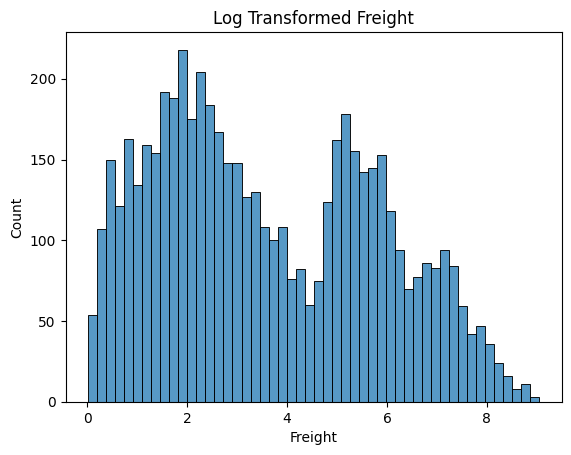

In [20]:
plt.figure()
sns.histplot(np.log1p(vendor['Freight']), bins=50)
plt.title("Log Transformed Freight")
plt.show()

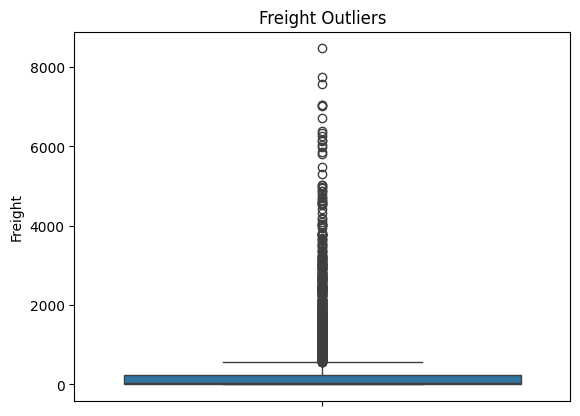

In [21]:
plt.figure()
sns.boxplot(y=vendor['Freight'])
plt.title("Freight Outliers")
plt.show()

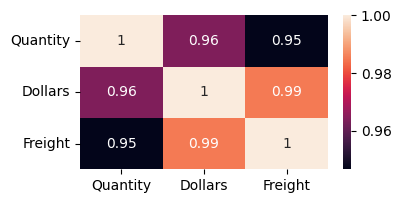

In [24]:
# Relation between Quantity, Dollar and Freight

plt.figure(figsize = (4,2))
sns.heatmap(vendor[['Quantity', 'Dollars', 'Freight']].corr(), annot = True)
plt.show()

Freight has moderate/high correlation with Dollars, indicating cost is a key factor in freight estimation.

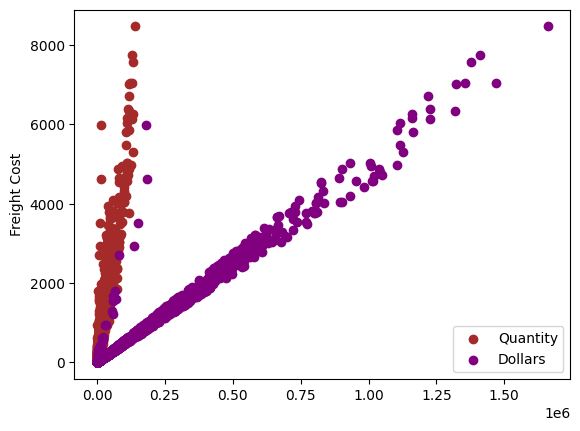

In [35]:
plt.scatter(vendor['Quantity'],vendor['Freight'], color = 'Brown')
plt.scatter(vendor['Dollars'],vendor['Freight'], color = 'Purple')
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [37]:
vendor['Cost_per_unit'] = vendor['Dollars'] / vendor['Quantity']
vendor['Freight_per_unit'] = vendor['Freight'] / vendor['Quantity']

In [38]:
vendor

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Cost_per_unit,Freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN,35.710000,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN,9.370000,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN,21.320000,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN,13.612255,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN,8.024419,0.221809
...,...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,NaN,17.366667,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,NaN,8.078943,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,NaN,20.594616,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,NaN,6.021237,0.033117


In [41]:
low_quantity = vendor['Quantity'].quantile(0.25)
high_quantity = vendor['Quantity'].quantile(0.75)
print(low_quantity)
print(high_quantity)

83.0
5100.5


In [47]:
print(vendor.loc[vendor['Quantity']<low_quantity,'Freight_per_unit'].mean())

0.09489854253138316


In [48]:
print(vendor.loc[vendor['Quantity']>high_quantity,'Freight_per_unit'].mean())

0.049077654690759046


“Freight cost shows economies of scale, where larger orders reduce per-unit shipping cost, while smaller orders have disproportionately higher freight per unit.”

In [52]:
vendor['Quantity_category'] = pd.cut(
    vendor['Quantity'],
    bins=[-1, low_quantity, high_quantity, vendor['Quantity'].max()],
    labels=['Low', 'Medium', 'High']
)

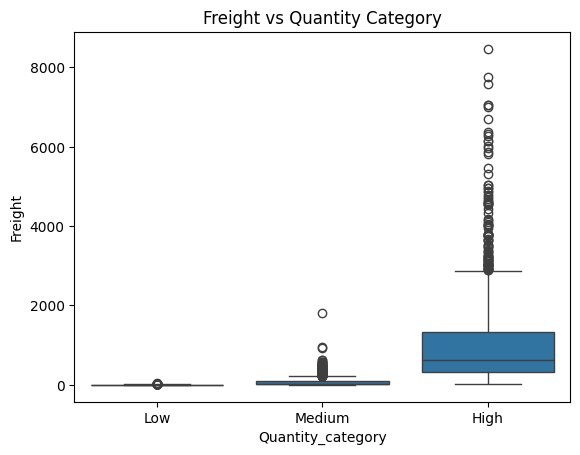

In [53]:
sns.boxplot(x='Quantity_category', y='Freight', data=vendor)
plt.title("Freight vs Quantity Category")
plt.show()

“Although freight increases with quantity, there is significant variability and extreme outliers in high-volume transactions, indicating inconsistent vendor pricing or potential anomalies.”

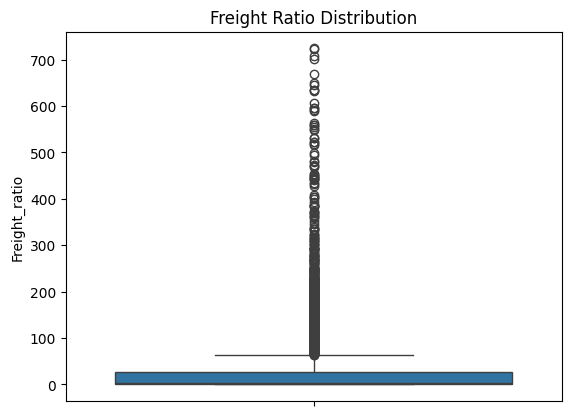

In [54]:
vendor['Freight_ratio'] = vendor['Freight'] / vendor['Cost_per_unit']
sns.boxplot(y=vendor['Freight_ratio'])
plt.title("Freight Ratio Distribution")
plt.show()

“Freight ratio distribution shows extreme outliers, indicating certain invoices have disproportionately high freight compared to cost

Training Models

In [91]:
X = vendor[['Quantity', 'Dollars']]
y = vendor['Freight']

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [93]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [94]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [95]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2 Score:", r2_score(y_true, y_pred))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
MAE: 24.4591807652632
MSE: 15482.522464835101
R2 Score: 0.9700197330175596

Decision Tree
MAE: 33.868417768760644
MSE: 33306.5290825595
R2 Score: 0.9355054296597022

Random Forest
MAE: 27.645808885229208
MSE: 19215.829725306776
R2 Score: 0.9627905784240083


“Simpler models can outperform complex models when the underlying relationship is linear and features are well-structured.”

Three regression models — Linear Regression, Decision Tree, and Random Forest — were trained using Quantity and Dollars as input features to predict Freight cost. Among these, Linear Regression achieved the best performance with an R² score of 0.97, along with the lowest MAE and MSE values.

In [97]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [24.45, 33.86, 27.64],
    'MSE': [15482.52, 33306.52, 19215.82],
    'R2 Score': [0.9700, 0.9355, 0.9627]
})

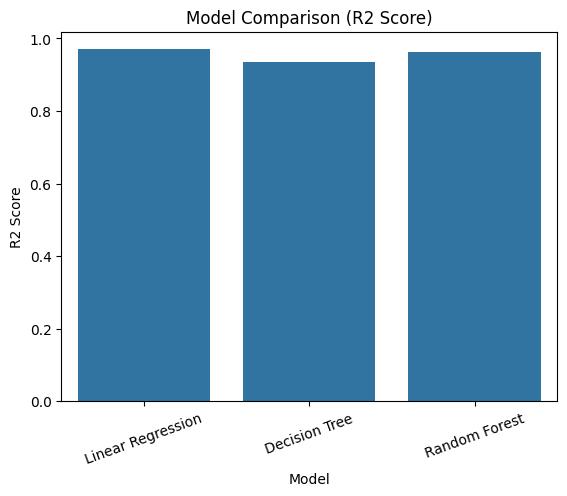

In [98]:
plt.figure()
sns.barplot(x='Model', y='R2 Score', data=results)
plt.title("Model Comparison (R2 Score)")
plt.xticks(rotation=20)
plt.show()

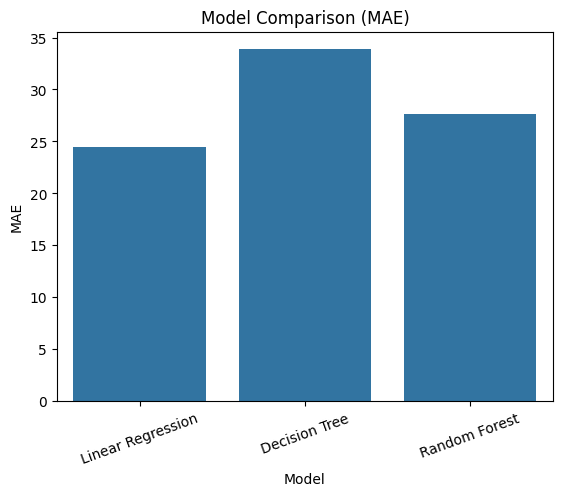

In [99]:
plt.figure()
sns.barplot(x='Model', y='MAE', data=results)
plt.title("Model Comparison (MAE)")
plt.xticks(rotation=20)
plt.show()

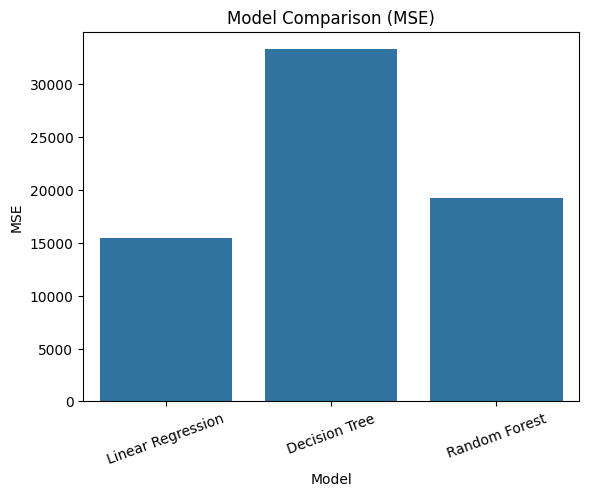

In [100]:
plt.figure()
sns.barplot(x='Model', y='MSE', data=results)
plt.title("Model Comparison (MSE)")
plt.xticks(rotation=20)
plt.show()

Linear Regression outperformed more complex models because the relationship between freight cost and input variables was largely linear. Tree-based models such as Decision Tree and Random Forest introduced unnecessary complexity, leading to slightly higher errors.

In [101]:
print("Train R2:", lr.score(X_train, y_train))
print("Test R2:", lr.score(X_test, y_test))

Train R2: 0.9707792745727539
Test R2: 0.9700197330175596


The model demonstrated strong generalization, as the training R² score (0.9707) was very close to the testing R² score (0.9700), indicating no overfitting.

Quantity and Dollars were found to be sufficient predictors of freight cost, as they directly represent shipment volume and value, which are key drivers of logistics cost.

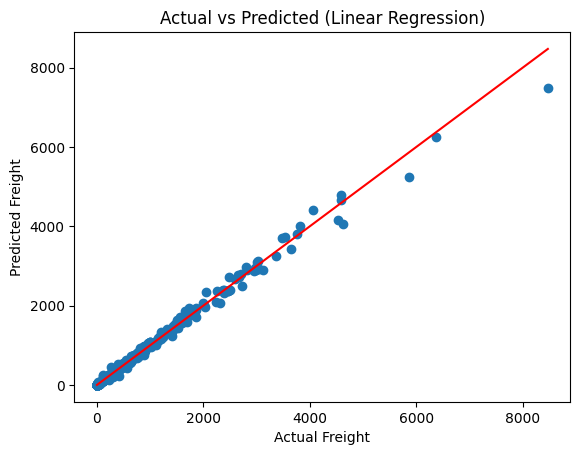

In [104]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Freight")
plt.ylabel("Predicted Freight")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

“I validated the model using actual vs predicted plots to visually assess prediction accuracy and error distribution.”

In [103]:
import pandas as pd

input_data = {
    "Quantity": [100, 500],
    "Dollars": [1850, 9000]
}

df = pd.DataFrame(input_data)

prediction = rf.predict(df)

print("Predicted Freight:", prediction)

Predicted Freight: [ 9.1359 43.4909]


The model effectively captures how freight cost scales with order size and value, making it suitable for real-world cost estimation and financial planning.